/tmp/ipykernel_219/2408978349.py:64: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos = s_to_xy(float(x[0]))


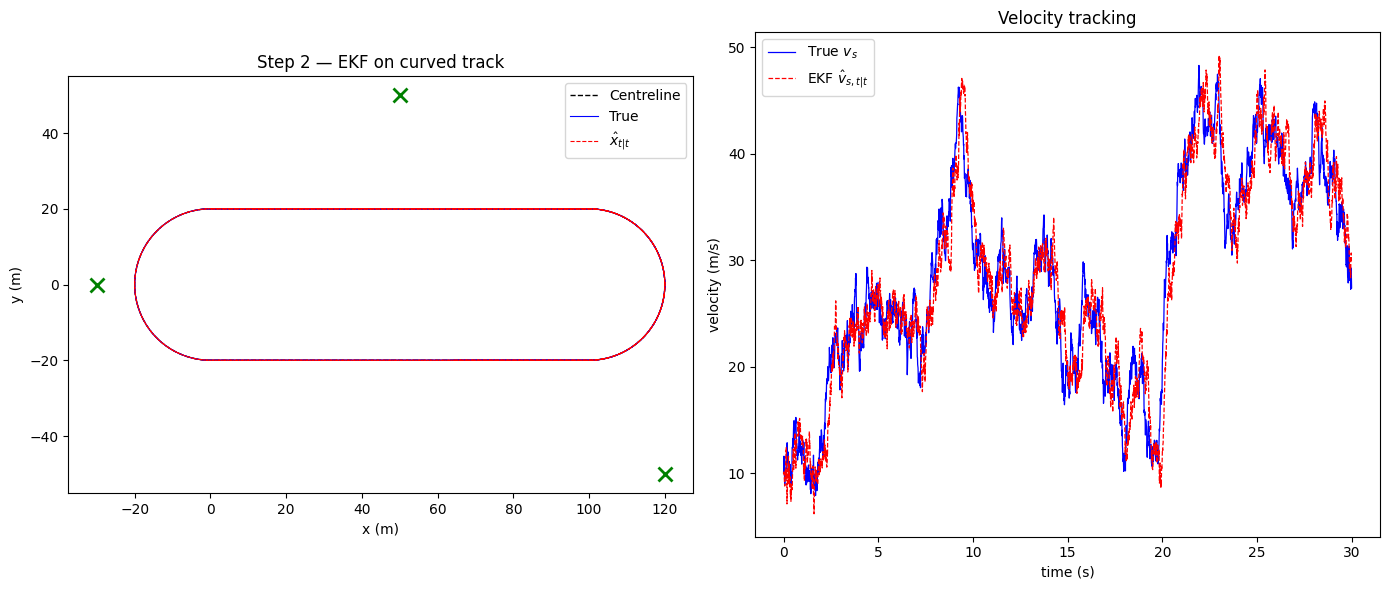

mean arc-length error: 0.315 m


In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Track geometry — functions from track_model.ipynb (member A: ChenhuiCui)
d   = 100.0
rho = 20.0
L   = 2*d + 2*np.pi*rho

def s_to_xy(s):
    s = s % L
    if s < d:
        return np.array([s, rho])
    elif s < d + np.pi*rho:
        theta = (s - d) / rho
        return np.array([d + rho*np.sin(theta), rho*np.cos(theta)])
    elif s < 2*d + np.pi*rho:
        return np.array([2*d + np.pi*rho - s, -rho])
    else:
        theta = (s - (2*d + np.pi*rho)) / rho
        return np.array([-rho*np.sin(theta), -rho*np.cos(theta)])

def s_to_normal(s):
    s = s % L
    if s < d:
        return np.array([0.0, -1.0])
    elif s < d + np.pi*rho:
        theta = (s - d) / rho
        return np.array([-np.sin(theta), -np.cos(theta)])
    elif s < 2*d + np.pi*rho:
        return np.array([0.0, 1.0])
    else:
        theta = (s - (2*d + np.pi*rho)) / rho
        return np.array([np.sin(theta), np.cos(theta)])

def sl_to_xy(s, ell):
    return s_to_xy(s) + ell * s_to_normal(s)

# system parameters
h = 0.01  # 100 Hz

# x_t = [s_t, v_t], model: x_{t+1} = A x_t + G w_t
A = np.array([[1, h],
              [0, 1]])
G = np.array([[0], [1]])

Q = 0.5
R = 1.5**2

# beacon positions (outside track, design parameter)
beacons = np.array([
    [ 50.0,  50.0],
    [120.0, -50.0],
    [-30.0,   0.0]
])
nb = len(beacons)

x_hat = np.array([[0.0], [10.0]])
P = np.diag([100.0, 25.0])


def meas_fn(x, v):
    pos = s_to_xy(float(x[0]))
    return np.array([
        np.linalg.norm(pos - beacons[i]) + v[i]
        for i in range(nb)
    ])


def meas_jac(x):
    eps = 1e-5
    H = np.zeros((nb, 2))
    h0 = meas_fn(x, np.zeros(nb))
    x_eps = x.copy(); x_eps[0] += eps
    h1 = meas_fn(x_eps, np.zeros(nb))
    H[:, 0] = (h1.flatten() - h0.flatten()) / eps
    return H


def measurement_update(P, x_hat, y):
    H = meas_jac(x_hat)
    S = H @ P @ H.T + R * np.eye(nb)
    innov = y - meas_fn(x_hat, np.zeros(nb))
    x_hat = x_hat + P @ H.T @ np.linalg.solve(S, innov.reshape(-1, 1))
    P = P - P @ H.T @ np.linalg.solve(S, H @ P)
    return P, x_hat


def time_update(P, x_hat):
    x_hat = A @ x_hat
    P = A @ P @ A.T + Q * (G @ G.T)
    return P, x_hat


# simulation
N = 3000
x_true = np.array([[0.0], [10.0]])

true_log = np.zeros((N, 2))
est_log  = np.zeros((N - 1, 2))
true_log[0] = x_true.T

for t in range(N - 1):
    y = meas_fn(x_true, np.random.normal(0, 1.5, nb))
    P, x_hat = measurement_update(P, x_hat, y)
    est_log[t] = x_hat.T
    P, x_hat = time_update(P, x_hat)
    x_true = A @ x_true + G * np.random.normal(0, np.sqrt(Q))
    true_log[t + 1] = x_true.T

# plots
s_vals   = np.linspace(0, L, 500)
track_xy = np.array([s_to_xy(s) for s in s_vals])
true_xy  = np.array([s_to_xy(s) for s in true_log[:, 0]])
est_xy   = np.array([s_to_xy(s) for s in est_log[:, 0]])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(track_xy[:, 0], track_xy[:, 1], 'k--', lw=1, label='Centreline')
axes[0].plot(true_xy[:, 0], true_xy[:, 1], 'b-', lw=0.8, label='True')
axes[0].plot(est_xy[:, 0],  est_xy[:, 1],  'r--', lw=0.8, label=r'$\hat{x}_{t|t}$')
for i, b in enumerate(beacons):
    axes[0].plot(b[0], b[1], 'gx', ms=10, mew=2)
axes[0].set_aspect('equal')
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')
axes[0].legend(); axes[0].set_title('Step 2 — EKF on curved track')

t_ax = np.arange(N) * h
axes[1].plot(t_ax,      true_log[:, 1], 'b-',  lw=0.9, label='True $v_s$')
axes[1].plot(t_ax[:-1], est_log[:,  1], 'r--', lw=0.9, label=r'EKF $\hat{v}_{s,t|t}$')
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('velocity (m/s)')
axes[1].legend(); axes[1].set_title('Velocity tracking')

plt.tight_layout()
plt.show()

err = np.abs(true_log[:-1, 0] - est_log[:, 0])
print(f'mean arc-length error: {np.mean(err):.3f} m')